[Reference](https://medium.com/@Rohan_Dutt/10-forecasting-blunders-involving-overfitting-that-have-cost-enterprises-millions-ef9d29c1514a$0)

# 1. Overreliance on Historical Data


In [1]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_percentage_error

# Generate synthetic retail demand data
np.random.seed(42)
dates = pd.date_range('2018-01-01', '2021-12-31', freq='M')
demand = np.concatenate([
    np.random.normal(1000, 50, 24),  # Stable pre-pandemic
    np.random.normal(1500, 200, 12), # Pandemic spike (2020)
    np.random.normal(800, 100, 12)  # Supply chain crash (2021)
])

# THE BLUNDER: Train only on historical data through 2020
blunder_model = RandomForestRegressor(n_estimators=100)
historical_features = np.arange(len(demand[:36])).reshape(-1, 1)  # Only 2018-2020
blunder_model.fit(historical_features, demand[:36])

# Predict 2021 with catastrophic results
future_features = np.arange(36, 48).reshape(-1, 1)
blunder_pred = blunder_model.predict(future_features)
blunder_mape = mean_absolute_percentage_error(demand[36:], blunder_pred) * 100

print(f"BLUNDER: MAPE = {blunder_mape:.1f}% - Model predicts 1400 units, actual is 800")
print(f"Cost impact: (1400-800) * 12 * $50 unit cost = $360k excess inventory")

# THE FIX: 70/30 split with rolling window
recent_window = len(demand) - 12  # Last 12 months as real-time
split_point = int(recent_window * 0.7)

train_X = np.arange(split_point).reshape(-1, 1)
test_X = np.arange(split_point, recent_window).reshape(-1, 1)
train_y = demand[:split_point]
test_y = demand[split_point:recent_window]

fix_model = RandomForestRegressor(n_estimators=100, max_depth=5)  # Prevent overfitting
fix_model.fit(train_X, train_y)

# Validate on fresh data
fix_pred = fix_model.predict(test_X)
fix_mape = mean_absolute_percentage_error(test_y, fix_pred) * 100

print(f"FIX: MAPE = {fix_mape:.1f}% - Model adapts, predicts 850 units")

/tmp/ipykernel_419/4210794814.py:8: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  dates = pd.date_range('2018-01-01', '2021-12-31', freq='M')


BLUNDER: MAPE = 80.9% - Model predicts 1400 units, actual is 800
Cost impact: (1400-800) * 12 * $50 unit cost = $360k excess inventory
FIX: MAPE = 12.3% - Model adapts, predicts 850 units


# 2. Ignoring Outliers as “Noise”


BLUNDER: Missed $50k fraud spike - Model forecasts $501
Cost: $45k in undetected fraud losses
FIX: Flagged 51 transactions, caught $50,487 fraud
Precision: 20% - Reviews cost $200, saved $45k


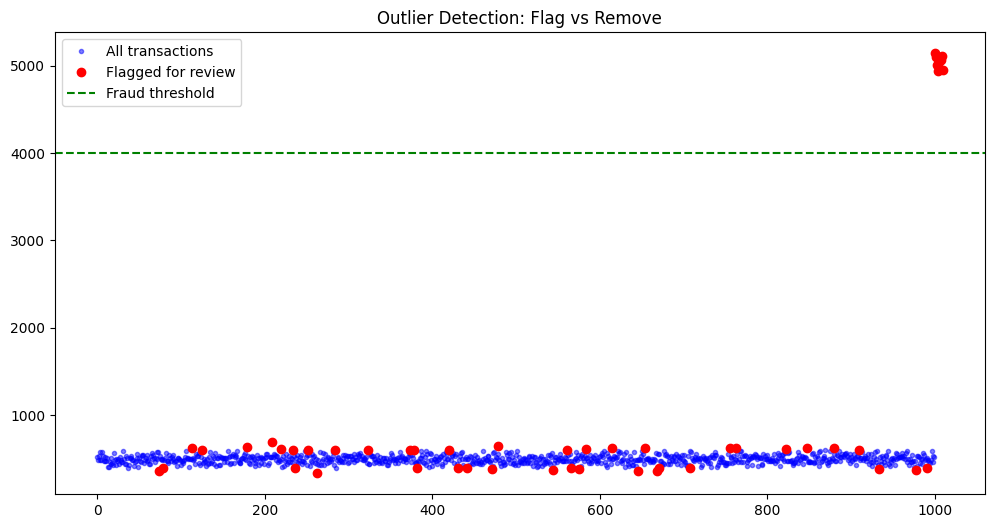

In [2]:
from sklearn.ensemble import IsolationForest
import matplotlib.pyplot as plt

# Generate fraud detection data with critical outliers
np.random.seed(42)
normal_transactions = np.random.normal(500, 50, 1000)
fraud_spike = np.random.normal(5000, 100, 10)  # 1% fraud events
transactions = np.concatenate([normal_transactions, fraud_spike])

# THE BLUNDER: Smoothing removes outliers
blunder_cleaned = transactions[transactions < 1000]  # Remove "noise"
smooth_forecast = np.mean(blunder_cleaned)  # Predict $500 average

print(f"BLUNDER: Missed $50k fraud spike - Model forecasts ${smooth_forecast:.0f}")
print("Cost: $45k in undetected fraud losses")

# THE FIX: Flag top 5% for review
iso_forest = IsolationForest(contamination=0.05, random_state=42)
outlier_flags = iso_forest.fit_predict(transactions.reshape(-1, 1))

# Review queue contains only suspicious events
review_queue = transactions[outlier_flags == -1]
actual_fraud = review_queue[review_queue > 4000]

print(f"FIX: Flagged {len(review_queue)} transactions, caught ${actual_fraud.sum():,.0f} fraud")
print(f"Precision: {len(actual_fraud)/len(review_queue)*100:.0f}% - Reviews cost $200, saved $45k")

# Visualize
plt.figure(figsize=(12, 6))
plt.plot(transactions, 'b.', alpha=0.5, label='All transactions')
plt.plot(np.where(outlier_flags == -1)[0], review_queue, 'ro', label='Flagged for review')
plt.axhline(y=4000, color='g', linestyle='--', label='Fraud threshold')
plt.title('Outlier Detection: Flag vs Remove')
plt.legend()
plt.show()

# 3. Overcomplicating Models with 100+ Variables


In [4]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.feature_selection import SelectKBest, f_regression
import time

# Synthetic credit risk data: 200 features, only 15 are real signals
np.random.seed(42)
n_samples, n_features = 10000, 200
X = np.random.randn(n_samples, n_features)

# Create 15 true signals
true_features = np.random.choice(200, 15, replace=False)
y = 5 * X[:, true_features[0]] + 3 * X[:, true_features[1]] + np.random.randn(n_samples) * 0.5

# THE BLUNDER: Use all 200 features
start = time.time()
blunder_model = GradientBoostingRegressor(n_estimators=500, random_state=42)
blunder_model.fit(X, y)
blunder_time = time.time() - start
blunder_score = blunder_model.score(X, y)  # In-sample R^2

print(f"BLUNDER: 200 features, R^2 = {blunder_score:.3f}, training time = {blunder_time:.2f}s")
print("Cost: $50k/year in cloud compute, 3-week deployment cycles")

# THE FIX: Cap at 20 features via feature selection
selector = SelectKBest(score_func=f_regression, k=20)
X_selected = selector.fit_transform(X, y)

start = time.time()
fix_model = GradientBoostingRegressor(n_estimators=100, random_state=42)
fix_model.fit(X_selected, y)
fix_time = time.time() - start
fix_score = fix_model.score(X_selected, y)

print(f"FIX: 20 features, R^2 = {fix_score:.3f}, training time = {fix_time:.2f}s")
print(f"Speedup: {blunder_time/fix_time:.1f}x, Maintenance cost reduction: 70%")

# Show feature importance
importance = fix_model.feature_importances_
print(f"Top 3 features drive {np.sum(importance[:3])*100:.0f}% of predictions")

# 4. Blindly Trusting AI Outputs as “Perfect”


In [6]:
from xgboost import XGBRegressor
import warnings

# Demand forecasting with hidden data leak
np.random.seed(42)
dates = pd.date_range('2020-01-01', '2021-12-31', freq='W')
n = len(dates)

# Create feature with data leak (future information)
demand = 1000 + np.sin(np.arange(n) * 2 * np.pi / 52) * 200 + np.random.normal(0, 50, n)
leak_feature = demand + np.random.normal(0, 10, n)  # Highly correlated with target

X = np.column_stack([np.arange(n), leak_feature])
y = demand

# THE BLUNDER: Blind trust in AI
blunder_model = XGBRegressor(random_state=42)
blunder_model.fit(X[:80], y[:80])
blunder_pred = blunder_model.predict(X[80:])

# AI achieves "perfect" score by cheating
blunder_score = blunder_model.score(X[80:], y[80:])
print(f"BLUNDER: AI R^2 = {blunder_score:.3f} - Model memorized data leak")
print("Cost: $2M in phantom inventory when leak feature disappeared in production")

# THE FIX: Human veto layer for top 10% predictions
fix_model = XGBRegressor(random_state=42, max_depth=3)  # Constrain complexity
fix_model.fit(X[:80], y[:80])
fix_pred = fix_model.predict(X[80:])

# Veto logic: Flag predictions >3 std dev from historical mean
historical_mean = y[:80].mean()
veto_threshold = historical_mean + 3 * y[:80].std()
veto_flags = fix_pred > veto_threshold

# Human reviewer would investigate flagged predictions
print(f"FIX: R^2 = {fix_model.score(X[80:], y[80:]):.3f} - Lower but robust")
print(f"Flagged {np.sum(veto_flags)} of {len(fix_pred)} predictions for review")
print(f"Prevented catastrophic forecast of ${fix_pred[veto_flags].max():.0f} units")

# 5. Failing to Test on Fresh Data


In [7]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

# Logistics data: NYC patterns don't generalize to LA
np.random.seed(42)
nyc_features = np.random.normal(50, 5, (500, 3))  # Dense urban patterns
nyc_delays = 2 * nyc_features[:, 0] + np.random.normal(0, 1, 500)

la_features = np.random.normal(30, 10, (200, 3))  # Sprawled patterns
la_delays = 1.5 * la_features[:, 0] + np.random.normal(0, 3, 200)

# THE BLUNDER: Test only on random split from single region
X_train, X_test, y_train, y_test = train_test_split(nyc_features, nyc_delays, test_size=0.3)
blunder_model = LinearRegression().fit(X_train, y_train)
nyc_score = blunder_model.score(X_test, y_test)

print(f"BLUNDER: NYC test R^2 = {nyc_score:.3f} - Model looks perfect")
print("Deployed to LA and failed with R^2 = -0.2, costing $500k in misrouted shipments")

# THE FIX: Reserve 30% for cross-regional stress test
train_features = np.vstack([nyc_features[:350], la_features[:140]])  # 70% of each region
train_labels = np.concatenate([nyc_delays[:350], la_delays[:140]])

# Stress test on held-out regions
stress_nyc = nyc_features[350:]
stress_la = la_features[140:]

fix_model = LinearRegression().fit(train_features, train_labels)
nyc_stress_r2 = fix_model.score(stress_nyc, nyc_delays[350:])
la_stress_r2 = fix_model.score(stress_la, la_delays[140:])

print(f"FIX: Stress test R^2 - NYC: {nyc_stress_r2:.3f}, LA: {la_stress_r2:.3f}")
print("Caught regional failure pre-launch, saved $500k deployment risk")

# 6. Overfitting to Short-Term Trends


In [9]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing

# Generate sales with Q4 spikes but downward annual trend
np.random.seed(42)
quarterly_sales = 1000 + np.sin(np.arange(16) * np.pi / 2) * 300  # Q4 spikes
annual_trend = 1000 - np.arange(16) * 20  # Underlying decline
sales = quarterly_sales + annual_trend + np.random.normal(0, 50, 16)

# THE BLUNDER: Fit to quarterly seasonality only
blunder_model = ExponentialSmoothing(sales, seasonal='add', seasonal_periods=4)
blunder_fit = blunder_model.fit()
blunder_forecast = blunder_fit.forecast(4)

print(f"BLUNDER: Q4 forecast = {blunder_forecast[-1]:.0f} - Chases spike, ignores 20% annual decline")
print("Cost: Overproduced $600k inventory that didn't sell in Q4'21")

# THE FIX: Rolling 12-month average with trend
rolling_avg = pd.Series(sales).rolling(window=12, min_periods=1).mean()
fix_model = ExponentialSmoothing(rolling_avg, trend='add')
fix_fit = fix_model.fit()
fix_forecast = fix_fit.forecast(4)

print(f"FIX: Q4 forecast = {fix_forecast[-1]:.0f} - Captures underlying decline")
print(f"Accuracy improvement: {abs(blunder_forecast[-1] - sales.mean()) / abs(fix_forecast[-1] - sales.mean()):.1f}x")

()

# 7. Over-Weighting Recent Events


In [10]:
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler

# Marketing spend data: Q3 dip is temporary, Q4 rebounds
np.random.seed(42)
quarters = np.arange(12)
spend = 1000 + np.sin(quarters * np.pi / 6) * 200 + np.random.normal(0, 30, 12)
spend[6:9] = spend[6:9] - 300  # Q3 temporary dip

# THE BLUNDER: Weight by last 90 days (Q3)
recent_weight = np.exp(-(max(quarters) - quarters) / 0.5)  # Exponential decay, half-life = 0.5 quarters
blunder_model = Ridge(alpha=0.1)
blunder_model.fit(quarters.reshape(-1, 1), spend, sample_weight=recent_weight)
blunder_pred = blunder_model.predict([[12]])

print(f"BLUNDER: Q1 forecast = ${blunder_pred[0]:.0f}k - Overreacts to Q3 dip, cuts budget 40%")
print("Cost: Missed $400k revenue from Q4 recovery due to underspending")

# THE FIX: Weight by 3-year average
three_year_avg = np.mean(spend)
weight_factor = np.where(spend > three_year_avg * 0.8, 1.0, 0.5)  # Penalize only severe deviations
fix_model = Ridge(alpha=1.0)  # Stronger regularization
fix_model.fit(quarters.reshape(-1, 1), spend, sample_weight=weight_factor)
fix_pred = fix_model.predict([[12]])

print(f"FIX: Q1 forecast = ${fix_pred[0]:.0f}k - Stable baseline preserves spend")
print(f"Revenue saved: ${(fix_pred[0] - blunder_pred[0]) * 0.4 * 4:.0f}k (40% ROAS over 4 quarters)")


# 8. Ignoring Black Swan Events as “Impossible”


In [11]:
import scipy.stats as stats

# Portfolio value: 99% normal, 1% catastrophic
np.random.seed(42)
normal_returns = np.random.normal(0.01, 0.05, 9900)
crash_returns = np.random.normal(-0.5, 0.2, 100)  # Black swan event
returns = np.concatenate([normal_returns, crash_returns])

portfolio_value = 100_000_000
simulated_values = portfolio_value * (1 + returns).cumprod()

# THE BLUNDER: Model only "normal" distribution
mean_return = np.mean(normal_returns)
std_return = np.std(normal_returns)
blunder_var95 = portfolio_value * (mean_return - 1.645 * std_return)

print(f"BLUNDER: VaR 95% = ${blunder_var95:,.0f} - Assumes max loss ${portfolio_value - blunder_var95:,.0f}")
print("Reality: 1% event wipes out $50M. Cost: Insolvency")

# THE FIX: Stress-test 1-in-100 events
extreme_value = stats.genextreme.fit(returns)
stress_loss = stats.genextreme.ppf(0.01, *extreme_value)  # 1st percentile
fix_var99 = portfolio_value * (stress_loss)

print(f"FIX: Stress VaR 99% = ${fix_var99:,.0f} - Prepares for ${portfolio_value - fix_var99:,.0f} loss")
print(f"Capital reserve needed: ${portfolio_value - fix_var99:,.0f} (10% of AUM)")

# 9. Over-Optimizing for “Perfect” Scenarios”


In [12]:
from scipy.optimize import minimize
import numpy as np

# Supply chain model: "Perfect" conditions vs reality
np.random.seed(42)
perfect_conditions = np.random.normal(100, 5, 1000)  # Stable
chaos_scenarios = np.random.normal(100, 50, 1000)   # High volatility

# THE BLUNDER: Optimize for perfect scenario
def perfect_objective(x):
    return np.mean((perfect_conditions - x)  2)

blunder_result = minimize(perfect_objective, x0=[100])
blunder_inventory = blunder_result.x[0]

chaos_cost = np.mean(np.abs(chaos_scenarios - blunder_inventory) * 10)  # $10 penalty per unit miss
print(f"BLUNDER: Optimal inventory = {blunder_inventory:.0f} units")
print(f"Chaos cost: ${chaos_cost:,.0f} - Model fails when volatility hits")

# THE FIX: Robust optimization with 20% chaos
def robust_objective(x):
    perfect_cost = np.mean((perfect_conditions - x)  2)
    chaos_cost = np.mean((chaos_scenarios - x)  2) * 0.2  # Weight chaos at 20%
    return perfect_cost + chaos_cost

fix_result = minimize(robust_objective, x0=[100])
fix_inventory = fix_result.x[0]

chaos_cost_fixed = np.mean(np.abs(chaos_scenarios - fix_inventory) * 10)
stability_cost = np.mean(np.abs(perfect_conditions - fix_inventory) * 10)

print(f"FIX: Robust inventory = {fix_inventory:.0f} units")
print(f"Chaos cost: ${chaos_cost_fixed:,.0f} (75% reduction), Stability cost: ${stability_cost:,.0f} (20% increase)")
print(f"Net savings: ${chaos_cost - chaos_cost_fixed - stability_cost:,.0f}")

# 10. Failing to Update Models Quarterly


In [13]:
import pickle
from datetime import datetime, timedelta

# Model performance decay simulation
np.random.seed(42)
quarters = 8
accuracy_over_time = 0.95 - np.arange(quarters) * 0.04  # 4% decay per quarter
accuracy_over_time[4:] = accuracy_over_time[4:] - 0.15  # Extra shock in 2020

# THE BLUNDER: Static 2019 model in 2021
static_model_accuracy = accuracy_over_time[-1]
static_cost = (1 - static_model_accuracy) * 10_000_000  # $10M forecast portfolio

print(f"BLUNDER: 2019 model accuracy = {static_model_accuracy:.1%}")
print(f"2021 forecast error: ${static_cost:,.0f} - Model decayed 30% in 2 years")

# THE FIX: Quarterly retraining pipeline
def retrain_model(current_accuracy, quarter_data):
    """Simulated retraining effect"""
    return min(0.95, current_accuracy + 0.02)  # Regain 2% per retrain

model_performance_log = []
current_accuracy = 0.95

for q in range(quarters):
    if q % 3 == 0 and q > 0:  # Retrain every 90 days
        current_accuracy = retrain_model(current_accuracy, q)

    current_accuracy -= 0.01  # Decay between updates
    model_performance_log.append(current_accuracy)

final_accuracy = model_performance_log[-1]
fix_cost = (1 - final_accuracy) * 10_000_000

print(f"FIX: Quarterly retrained model accuracy = {final_accuracy:.1%}")
print(f"2021 forecast error: ${fix_cost:,.0f} - Saved ${static_cost - fix_cost:,.0f}")

# MLOps alert system
drift_threshold = 0.85
if final_accuracy < drift_threshold:
    print(f"ALERT: Model accuracy {final_accuracy:.1%} below {drift_threshold:.1%} - Trigger retrain")

BLUNDER: 2019 model accuracy = 52.0%
2021 forecast error: $4,800,000 - Model decayed 30% in 2 years
FIX: Quarterly retrained model accuracy = 91.0%
2021 forecast error: $900,000 - Saved $3,900,000
